In [ ]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from db_connection import get_connection
from deep_translator import GoogleTranslator

# Connect to database
conn = get_connection()
print("Connected successfully!")

Connected successfully!


In [ ]:
# load seller dispatch analysis dataframe
df_seller = pd.read_sql("SELECT * FROM core.seller_dispatch_analysis_view", conn)
print(df_seller.shape)
df_seller

C:\Users\Ezeike Promse Chime\AppData\Local\Temp\ipykernel_25944\2839985648.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_seller = pd.read_sql("SELECT * FROM core.seller_dispatch_analysis_view", conn)


(14, 6)


,review_score,seller_dispatch_days,carrier_delivery_days,actual_delivery_days,estimated_delivery_days,delivery_status
0,1,26.0,3.0,29.0,20.0,Late
1,1,18.0,1.0,19.0,12.0,Late
2,1,18.0,2.0,20.0,12.0,Late
3,1,23.0,16.0,39.0,29.0,Late
4,1,23.0,24.0,47.0,32.0,Late
5,1,15.0,14.0,30.0,11.0,Late
6,1,22.0,4.0,26.0,19.0,Late
7,1,23.0,7.0,31.0,21.0,Late
8,1,5.0,7.0,13.0,19.0,On Time
9,1,22.0,1.0,24.0,12.0,Late


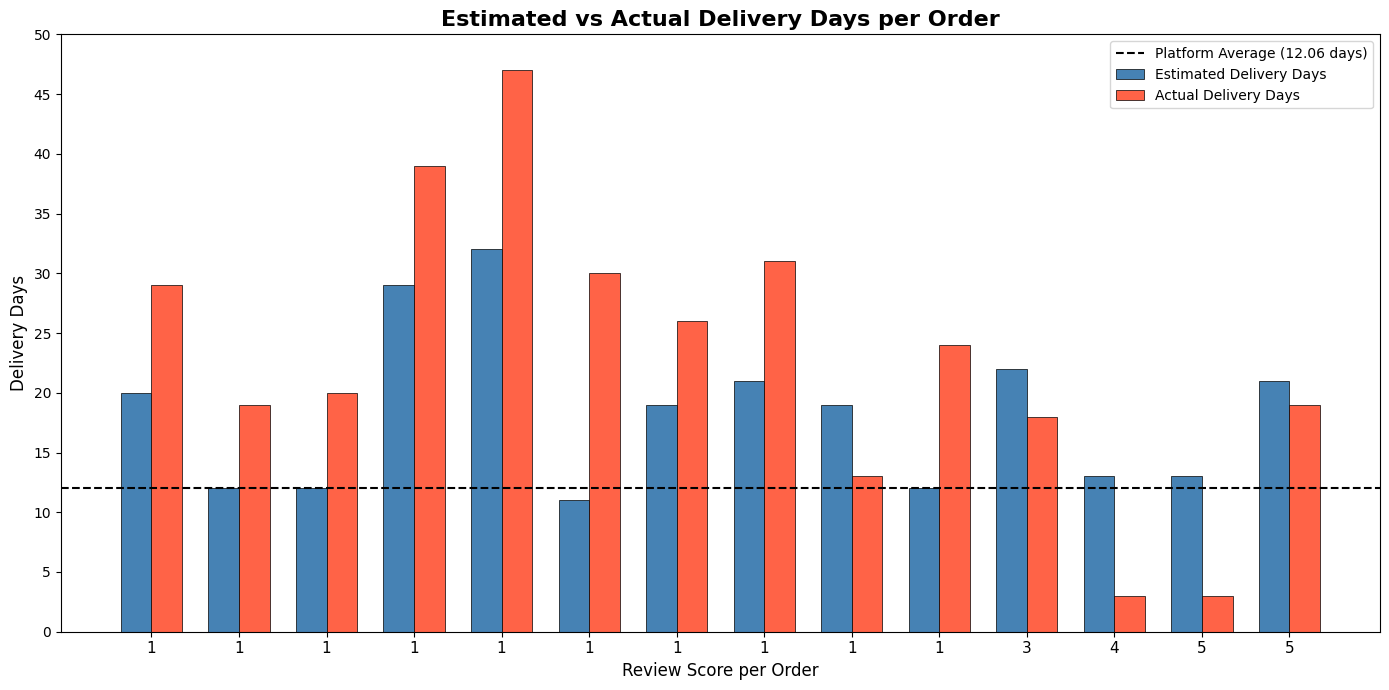

In [30]:
# Set up bar positions
x = np.arange(len(df_seller))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

# Plot estimated and actual bars side by side
bars1 = ax.bar(x - width/2, df_seller['estimated_delivery_days'], 
               width, label='Estimated Delivery Days', 
               color='steelblue', edgecolor='black', linewidth=0.5)

bars2 = ax.bar(x + width/2, df_seller['actual_delivery_days'], 
               width, label='Actual Delivery Days', 
               color='tomato', edgecolor='black', linewidth=0.5)

# X axis labels — review score per order
ax.set_xticks(x)
ax.set_xticklabels(df_seller['review_score'], fontsize=11)

ax.set_title('Estimated vs Actual Delivery Days per Order', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Review Score per Order', fontsize=12)
ax.set_ylabel('Delivery Days', fontsize=12)
ax.legend()

# Y axis intervals of 5
ax.set_yticks(np.arange(0, df_seller['actual_delivery_days'].max() + 5, 5))

# Platform average line
ax.axhline(y=12.06, color='black', linestyle='--', 
           label='Platform Average (12.06 days)')
ax.legend()

plt.tight_layout()

# Save
plt.savefig('../dashboards/delivery_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
conn.rollback()
df_comparison = pd.read_sql("SELECT * FROM core.seller_vs_platform_view", conn)
df_comparison

C:\Users\Ezeike Promse Chime\AppData\Local\Temp\ipykernel_25944\1035050936.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_comparison = pd.read_sql("SELECT * FROM core.seller_vs_platform_view", conn)


,seller_label,avg_dispatch_days,avg_carrier_days,avg_actual_days
0,This Seller,15.21,7.29,22.93
1,Platform Average,2.74,8.85,12.06


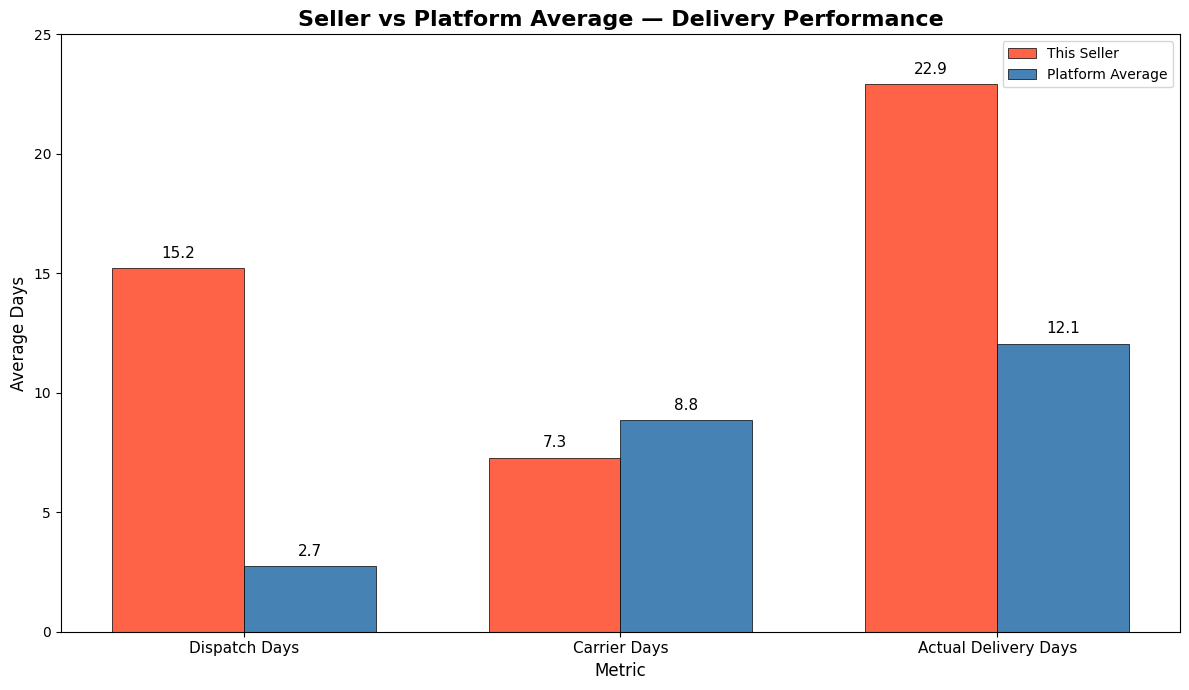

In [ ]:
# Data
metrics = ['Dispatch Days', 'Carrier Days', 'Actual Delivery Days']

seller_values = df_comparison[df_comparison['seller_label'] == 'This Seller'][
    ['avg_dispatch_days', 'avg_carrier_days', 'avg_actual_days']].values[0]

platform_values = df_comparison[df_comparison['seller_label'] == 'Platform Average'][
    ['avg_dispatch_days', 'avg_carrier_days', 'avg_actual_days']].values[0]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars
bars1 = ax.bar(x - width/2, seller_values, width,
               label='This Seller',
               color='tomato', edgecolor='black', linewidth=0.5)

bars2 = ax.bar(x + width/2, platform_values, width,
               label='Platform Average',
               color='steelblue', edgecolor='black', linewidth=0.5)

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=11)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=11)

# Labels
ax.set_title('Seller vs Platform Average — Delivery Performance',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Average Days', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_yticks(np.arange(0, max(seller_values) + 5, 5))
ax.legend()

plt.tight_layout()

# Save
plt.savefig('../dashboards/seller_vs_platform.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
df_comments = pd.read_sql("SELECT * FROM core.seller_reviews_comments_view", conn)
df_comments = df_comments.dropna(subset=['review_comment_message'])
print(f"Total comments: {len(df_comments)}")
df_comments['comment_length'] = df_comments['review_comment_message'].str.len()
df_comments

C:\Users\Ezeike Promse Chime\AppData\Local\Temp\ipykernel_4840\1383740291.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_comments = pd.read_sql("SELECT * FROM core.seller_reviews_comments_view", conn)


Total comments: 11


,review_score,delivery_status,review_comment_message,comment_length
0,5,On Time,Excelente,9
1,1,Late,parceria sem responsabilidade,29
3,5,On Time,"Bom produto, entregue no prazo.",31
4,1,Late,Se houve alguma dificuldade para entrega do pr...,137
5,1,Late,"Comprei pela segunda vez e ainda não recebi, p...",173
6,1,Late,Até agora só transtorno por causa desse produto.,48
7,3,On Time,"Falta a Nota Fiscal DANFE, favor enviar.",40
8,1,Late,"NÃO RECEBI AINDA MEU PRODUTO, AGUARDO UM RETOR...",56
9,1,Late,Prazo longo e ainda atraso na entrega. Até o m...,186
10,1,Late,"Demora em tirar nota fiscal, sem retorno da si...",63


In [ ]:
translator = GoogleTranslator(source='pt', target='en')

df_comments['english_translation'] = df_comments['review_comment_message'].apply(
    lambda x: translator.translate(x) if isinstance(x, str) else x
)
# Show full text in all columns
pd.set_option('display.max_colwidth', None)

df_comments[['review_comment_message', 'english_translation']]

,review_comment_message,english_translation
0,Excelente,Excellent
1,parceria sem responsabilidade,partnership without responsibility
3,"Bom produto, entregue no prazo.","Good product, delivered on time."
4,"Se houve alguma dificuldade para entrega do produto, no mínimo, o comprador deveria ser avisado e negociado uma nova situação de entrega.","If there were any difficulties in delivering the product, at the very least, the buyer should be notified and a new delivery situation negotiated."
5,"Comprei pela segunda vez e ainda não recebi, parceiro das Lojas lannister, não informa o cliente sobre emissão de NF e a entrega, tenho que ficar cobrando status do processo","I bought it for the second time and I still haven't received it, a partner at Lannister Stores, they don't inform the customer about the invoice issuance and delivery, I have to keep charging the status of the process"
6,Até agora só transtorno por causa desse produto.,"So far, it's just inconvenience because of this product."
7,"Falta a Nota Fiscal DANFE, favor enviar.","The DANFE Invoice is missing, please send it."
8,"NÃO RECEBI AINDA MEU PRODUTO, AGUARDO UM RETORNO URGENTE","I HAVE NOT RECEIVED MY PRODUCT YET, I WAITING FOR AN URGENT RETURN"
9,Prazo longo e ainda atraso na entrega. Até o momento não recebi o produto e não tenho uma satisfação do que realmente está havendo. Segundo correio o produto ainda não chegou ao destino.,"Long deadline and still late delivery. So far I haven't received the product and I'm not sure what's really going on. According to the post, the product has not yet reached its destination."
10,"Demora em tirar nota fiscal, sem retorno da situação da compra!","It takes a long time to get an invoice, with no return on the status of the purchase!"


In [11]:
import re
from wordcloud import WordCloud, STOPWORDS

# Combine all translated comments into one string
all_text = ' '.join(df_comments['english_translation'].dropna().tolist())

# Convert to lowercase
all_text = all_text.lower()

# Remove punctuation and special characters
all_text = re.sub(r'[^a-z\s]', '', all_text)

# Define stopwords — common words to exclude
stopwords = set(STOPWORDS)

# Add custom stopwords irrelevant to your analysis
stopwords.update(['product', 'i', 'the', 'a', 'and', 'to', 'of', 
                  'was', 'is', 'it', 'in', 'that', 'have', 'for',
                  'on', 'with', 'this', 'my', 'me', 'not', 'but',
                  'they', 'very', 'will', 'just', 'did', 'do'])

print(all_text)  # preview first 500 characters

excellent partnership without responsibility good product delivered on time if there were any difficulties in delivering the product at the very least the buyer should be notified and a new delivery situation negotiated i bought it for the second time and i still havent received it a partner at lannister stores they dont inform the customer about the invoice issuance and delivery i have to keep charging the status of the process so far its just inconvenience because of this product the danfe invoice is missing please send it i have not received my product yet i waiting for an urgent return long deadline and still late delivery so far i havent received the product and im not sure whats really going on according to the post the product has not yet reached its destination it takes a long time to get an invoice with no return on the status of the purchase my product is missing from the tax office im going to pursue my rights


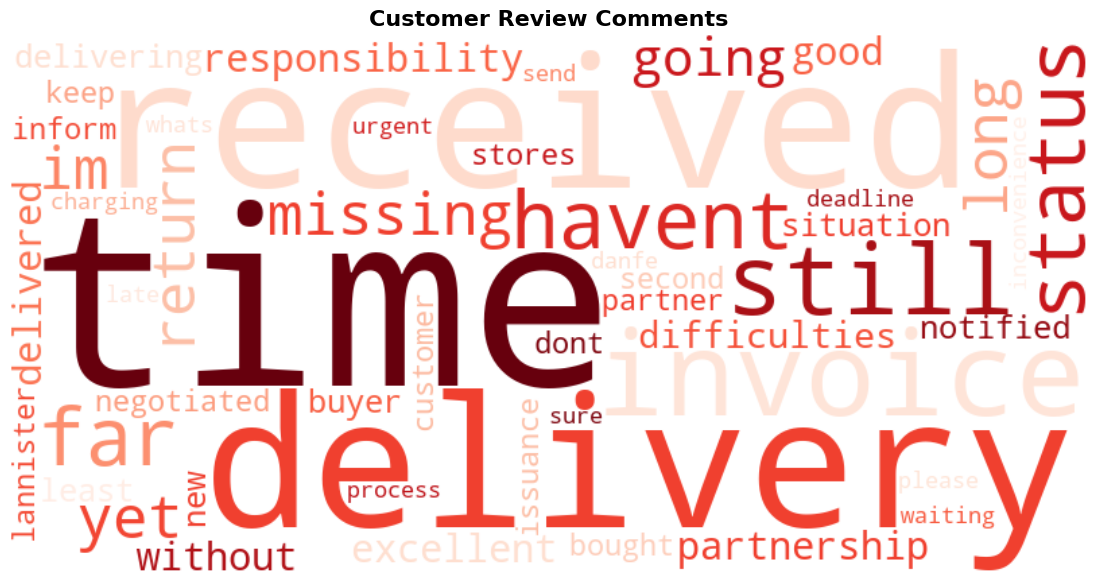

In [ ]:
# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords,
    max_words=50,
    colormap='Reds'
).generate(all_text)

# Display
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Customer Review Comments',
          fontsize=16, fontweight='bold')

# Save
plt.savefig('../dashboards/wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()